<a href="https://colab.research.google.com/github/yeonsub/Learning_Material_for_Creation/blob/main/Transformer_latent_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Flow Model


### Conceptual Changes for Flow Matching

To switch from a Diffusion Model to a Flow Matching model, we need to adapt several components:

1.  **Model Architecture**: The current U-Net (`ConditionalTimeEmbeddingModel`) might be adaptable, but its output interpretation will change. Instead of predicting noise `eps`, it will need to predict a vector field `v`.
2.  **Variance Schedule (Path Definition)**: Instead of `alpha_prod` for diffusion, we'll define a simple *conditional probability path* $p_t(x | x_0, x_1)$ (or *reference flow*) that smoothly interpolates between a data point $x_0$ and a noisy point $x_1$. A common choice is a straight path:
    $$ x_t = (1 - t)x_0 + tx_1 $$
3.  **Loss Function**: The `do_step` function will be entirely different. The Flow Matching loss aims to minimize the squared difference between the neural network's predicted vector field and the true tangent vector of the conditional path. For a straight path, the target vector field is often $(x_1 - x_0)$ or a scaled version of it.
    $$ L = E_{t \sim U(0,1), x_0 \sim p_{data}, x_1 \sim p_{noise}} [ \| v_{\theta}(x_t, t) - (x_1 - x_0) \|^2 ] $$
4.  **Sampling (Inference)**: Instead of iterative denoising, sampling involves numerically integrating the learned vector field $v_{\theta}(x, t)$ from $t=1$ (noise) down to $t=0$ (data) using an ODE solver (e.g., Euler, Runge-Kutta).


## Data Loading and Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
from torch.nn.functional import cross_entropy
from torchvision.datasets import MNIST
import math
from itertools import chain
import os
import scipy

Start by setting up some plotting defaults

In [2]:
plot_alpha = 0.0
is_dark = True
if is_dark:
    pyplot_context = 'dark_background'
    binary_cmap = LinearSegmentedColormap.from_list(name='binary_alpha', colors=[(0,0,0,plot_alpha), (1,1,1,1)])
else:
    pyplot_context = 'default'
    binary_cmap = LinearSegmentedColormap.from_list(name='binary_alpha', colors=[(1,1,1,1), (0,0,0,plot_alpha)])

We then check if cuda is available and disable gradient calculations for the time being as we explore.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Get the mnist dataset

In [4]:
data_train = MNIST('.', download=True, train=True)
data_test  = MNIST('.', download=True, train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


Normalize the dataset such that pixel values are between -1 and 1 and pad the images to make them 32x32.

In [5]:
# Here we normalize the mnist image values to lie between -1 and 1.
x_train = 2.0 * (data_train.data / 255.0 - 0.5)
x_val   = 2.0 * (data_test.data / 255.0 - 0.5)
y_train = data_train.targets
y_val   = data_test.targets

# We also pad the images with a 2 pixel border so that they are 32x32.
# This makes it easier to work with the convnet we define later.
x_train = torch.nn.functional.pad(x_train, (2,2,2,2), value=-1)[...,None]
x_val   = torch.nn.functional.pad(x_val, (2,2,2,2), value=-1)[...,None]

## Diffusion Model Setup

### Variational Encoder and Latent Variable Dataset

To train the latent diffusion model we first need to generate latents for our MNIST dataset. We will generate the latents using VAE.

In [6]:
class ConvBlock(torch.nn.Module):
    def __init__(self, fin, fout, *args, **kwargs):
        super(ConvBlock, self).__init__()
        self._conv = torch.nn.Conv2d(fin, fout, *args, **kwargs)
        self._norm = torch.nn.BatchNorm2d(fout)
        self._relu = torch.nn.LeakyReLU()

    def forward(self, x):
        return self._relu(self._norm(self._conv(x)))

class ConvEncoder(torch.nn.Module):
    def __init__(self, features):
        super(ConvEncoder, self).__init__()

        layers   = []
        for i in range(len(features)-1):
            fi = features[i]
            fo = features[i+1]
            if i > 0:
                layers.append(torch.nn.Sequential(
                    torch.nn.MaxPool2d(2),
                    ConvBlock(fi, fo, 3, padding='same'),
                    ConvBlock(fo, fo, 3, padding='same'),
                ))
            else:
                layers.append(torch.nn.Sequential(
                    ConvBlock(fi, fo, 3, padding='same'),
                    ConvBlock(fo, fo, 3, padding='same'),
                ))
        self.features = features
        self.layers = torch.nn.ModuleList(layers)


    def forward(self, x):
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

class ConvDecoder(torch.nn.Module):
    def __init__(self, features):
        super(ConvDecoder, self).__init__()

        layers = []
        for i in range(len(features)-1):
            layer = []

            fi = features[i]
            fo = features[i+1]

            if i > 0:
                layer += [
                    torch.nn.Upsample(scale_factor=2),#, mode='bilinear'),
                    ConvBlock(fi, fi, 3, padding='same'),
                ]

            if i < len(features)-2:
                layer += [
                    ConvBlock(fi, fi, 3, padding='same'),
                    ConvBlock(fi, fo, 3, padding='same'),
                ]
            else:
                layer += [
                    ConvBlock(fi, fi, 3, padding='same'),
                    torch.nn.Conv2d(fi, fo, 3, padding='same'),
                ]


            layers.append(torch.nn.Sequential(*layer))

        self.layers = torch.nn.ModuleList(layers)


    def forward(self, x):
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

Let's define some parameters for the VAE

In [7]:
features = [1, 16, 32, 64] # Increased VAE model capacity
latent_channels = 2
batch_size    = 128
learning_rate = 1e-3
num_epochs    = 200

latent_resolution = x_train.shape[1] // (1 << (len(features) - 1))
latent_shape = (latent_channels, latent_resolution, latent_resolution)

encoder = ConvEncoder(features + [2 * latent_channels,])
decoder = ConvDecoder([latent_channels,] + features[::-1])

### 기존 학습된 VAE 활용
If you have already trained the VAE, load it. Be sure you skip the following training cells, otherwise you'll have to reload it.

In [8]:
# # If your VAE is saved to the local drive, you can skip loading it from your google drive.
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Colab Notebooks/autoencoder/variational_encoder.pt" .
!cp "/content/drive/MyDrive/Colab Notebooks/autoencoder/variational_decoder.pt" .

print('Number of parameters:', np.sum([torch.numel(x) for x in list(chain(encoder.parameters(),decoder.parameters()))]))

encoder.load_state_dict(torch.load('variational_encoder.pt', map_location=device))
decoder.load_state_dict(torch.load('variational_decoder.pt', map_location=device))
encoder = encoder.to(device)
decoder = decoder.to(device)

Mounted at /content/drive
Number of parameters: 196867


### 없으면 VAE 생성 후 학습
Let us now create the VAE and train it.

In [51]:
optimizer = torch.optim.Adam(chain(encoder.parameters(), decoder.parameters()), learning_rate)

print('Number of parameters:', np.sum([torch.numel(x) for x in list(chain(encoder.parameters(),decoder.parameters()))]))

encoder = encoder.to(device)
decoder = decoder.to(device)

Number of parameters: 196867


In [52]:
print_every = 10
num_batches = int(math.ceil(x_train.shape[0] / batch_size))
encoder.train()
decoder.train()

avg_loss = 0.0
mean_rec = 0.0
mean_kl  = 0.0
for i in range(num_epochs):
    train_ids = torch.randperm(x_train.shape[0])
    for bid in range(num_batches):
        with torch.no_grad():
            batch_ids = train_ids[bid*batch_size:(bid+1)*batch_size]
            x = x_train[batch_ids,...]
            x = x.to(device)
            x = torch.transpose(x, 1, 3)

        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        new_x = decoder(z)

        reconstruction_loss = torch.sum((new_x - x)**2, dim=[1,2,3])
        sigma2 = sigma**2
        kl_loss = 0.5 * torch.sum(sigma2 + mu**2 - torch.log(sigma2) - 1.0, dim=[1,2,3])
        loss = reconstruction_loss + kl_loss
        loss = torch.mean(loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            avg_loss += loss.cpu().numpy() / num_batches
            mean_rec += torch.mean(reconstruction_loss).cpu().numpy() / num_batches
            mean_kl  += torch.mean(kl_loss).cpu().numpy() / num_batches

    if (i + 1) % print_every == 0:
      print(i, avg_loss / print_every, mean_rec / print_every, mean_kl / print_every)
      avg_loss = 0.0
      mean_rec = 0.0
      mean_kl  = 0.0


9 63.445454 29.456955 33.988533
19 63.201435 29.326538 33.87492
29 63.012573 29.239817 33.77273
39 62.828575 29.156393 33.672318
49 62.630898 29.053345 33.577473
59 66.54348 29.256145 37.287365
69 65.7175 28.403986 37.313587
79 64.89412 28.678528 36.21555
89 64.48665 28.80227 35.684307
99 66.067276 28.368275 37.69888


Let's now save the model, and copy the saved model to your google drive.

In [53]:
torch.save(encoder.state_dict(), 'variational_encoder.pt')
torch.save(decoder.state_dict(), 'variational_decoder.pt')

# Optionally, copy the model to your google drive so you can retrieve it later.
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/autoencoder/', exist_ok=True)
!cp variational_encoder.pt "/content/drive/MyDrive/Colab Notebooks/autoencoder/"
!cp variational_decoder.pt "/content/drive/MyDrive/Colab Notebooks/autoencoder/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 모델을 사용하여 잠재 공간의 데이타 생성
Let's now pass our dataset to the encoder to produce the latent variables. We produce two sets of data, lat_train and lat_val, corresponding to the training and validation sets respectively.

In [54]:
# Prepare latent data for diffusion model
encoder.eval()

# Train data
num_batches = int(math.ceil(x_train.shape[0] / batch_size))
lat_train = []
with torch.no_grad():
    for bid in range(num_batches):
        x = x_train[bid*batch_size:(bid+1)*batch_size,...]
        x = x.to(device)
        x = torch.transpose(x, 1, 3)

        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        lat_train.append(z.cpu())

lat_train = torch.cat(lat_train)

# Validation data
num_batches = int(math.ceil(x_val.shape[0] / batch_size))
lat_val = []
with torch.no_grad():
    for bid in range(num_batches):
        x = x_val[bid*batch_size:(bid+1)*batch_size,...]
        x = x.to(device)
        x = torch.transpose(x, 1, 3)

        mu_sigma = encoder(x)
        mu    = mu_sigma[:,:latent_channels,:,:]
        sigma = mu_sigma[:,latent_channels:,:,:]
        z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu
        lat_val.append(z.cpu())

lat_val = torch.cat(lat_val)

Let's make sure that our model outputs what expected. Let's plot a few MNIST characters and how the VAE represents them.

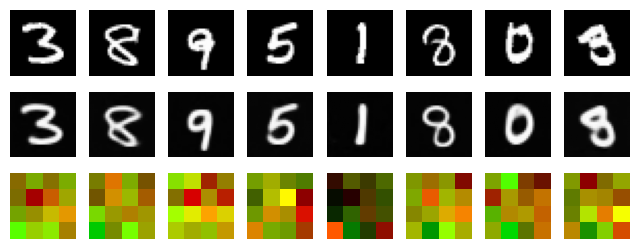

In [76]:
fig, axes = plt.subplots(3,8, figsize=(8,3))
perm = torch.randperm(x_val.shape[0])[:8]
d = x_val[perm,...].to(device)
with torch.no_grad():
    encoder.eval()
    decoder.eval()

    mu_sigma = encoder(torch.transpose(d, 1, 3))
    mu    = mu_sigma[:,:latent_channels,:,:]
    sigma = mu_sigma[:,latent_channels:,:,:]
    z = torch.normal(0, 1, size=mu.shape, device=device) * sigma + mu

    pred = decoder(z)
    pred = torch.transpose(pred, 1, 3)
    lat  = torch.transpose(z, 1, 3)


for i in range(8):
    x = d[i,:,:,0].cpu().numpy()
    y = pred[i,:,:,0].cpu().numpy()
    z = lat[i,:,:,:].cpu().numpy()
    z = (z - np.min(z)) / (np.max(z) - np.min(z))
    axes[0,i].imshow(x, cmap='gray')
    axes[0,i].axis('off')
    axes[1,i].imshow(y, cmap='gray')
    axes[1,i].axis('off')
    axes[2,i].imshow(np.pad(z, [(0,0), (0,0), (0, 1)]), cmap='gray')
    axes[2,i].axis('off')
plt.show()

## Flow Matching Model

Flow Matching is a class of generative models that learns a continuous-time transformation between a simple noise distribution (e.g., standard Gaussian) and a complex data distribution. Unlike Diffusion Models that typically learn a score function or a denoising function to reverse a stochastic process, Flow Matching directly learns a vector field `v(x, t)` that governs a deterministic Ordinary Differential Equation (ODE):

$$ \frac{dx}{dt} = v(x, t) $$

This ODE defines a flow that transports samples from one distribution to another. The training objective is to match the learned vector field to a simpler, analytically tractable target vector field that transports samples along a pre-defined path (e.g., a straight line) between noise and data. This often makes sampling faster and more stable compared to some diffusion processes, as it's a deterministic process rather than a stochastic one during inference.

Now let's build the latent model architecture. We start by defining a positional embedding for the time variable.

In [11]:
class SinusoidalPositionEmbedding(torch.nn.Module):
    def __init__(self, dim=16, scale=10000.0):
        super().__init__()
        half_dim = dim // 2
        emb_scale = math.log(scale) / (half_dim - 1)
        self.emb_factor = torch.exp(-emb_scale * torch.arange(half_dim, device=device))

    def forward(self, time):
        embeddings = time[:, None] * self.emb_factor[None,:]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

### Transformer 기반 모델 아키텍처

Transformer 기반의 모델을 정의합니다. 다음은 핵심 구성 요소인 `PatchEmbedding`과 `TransformerBlock` 정의입니다.

In [1]:
class PatchEmbedding(torch.nn.Module):
    def __init__(self, in_channels, patch_size, embed_dim, latent_resolution):
        super().__init__()
        # Patching and linear projection
        self.patch_size = patch_size
        self.proj = torch.nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Calculate number of patches
        self.num_patches = (latent_resolution // patch_size) ** 2

        # Learnable positional embeddings
        self.position_embedding = torch.nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x: (B, C, H, W)
        # Convert to patches: (B, E, H/P, W/P)
        x = self.proj(x)
        # Flatten patches: (B, E, N_patches) -> (B, N_patches, E)
        x = x.flatten(2).transpose(1, 2)
        # Add positional embedding
        x = x + self.position_embedding
        return x

class TransformerBlock(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4., dropout=0.1):
        super().__init__()
        self.norm1 = torch.nn.LayerNorm(embed_dim)
        self.attn = torch.nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = torch.nn.LayerNorm(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, mlp_hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(mlp_hidden_dim, embed_dim),
            torch.nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

NameError: name 'torch' is not defined

이제 `PatchEmbedding`과 `TransformerBlock`을 사용하여 `LatentFlowTransformerModel`을 정의합니다.

이 모델은 시간(`t`)과 클래스(`y`) 임베딩을 패치 임베딩에 직접 더하여 조건부 정보를 통합합니다. 또한, Transformer 블록을 통과한 후 토큰을 다시 공간 그리드로 재구성하고, 최종적으로 벡터 필드를 예측합니다.

In [ ]:
class LatentFlowTransformerModel(torch.nn.Module):
    def __init__(self,
                 latent_channels,
                 latent_resolution,
                 embed_dim,         # Dimension of Transformer tokens
                 patch_size,        # Size of image patches (e.g., 2 for 2x2 patches)
                 num_transformer_blocks,
                 num_heads,
                 time_embedding_dim,
                 num_classes,
                 class_embedding_dim,
                 dropout=0.1):
        super().__init__()

        self.latent_channels = latent_channels
        self.latent_resolution = latent_resolution
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.num_patches = (latent_resolution // patch_size) ** 2

        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(latent_channels, patch_size, embed_dim, latent_resolution)

        # 2. Time Embedding
        self.time_embedding = torch.nn.Sequential(
            SinusoidalPositionEmbedding(time_embedding_dim), # Reusing the existing sinusoidal embedding
            torch.nn.Linear(time_embedding_dim, embed_dim),
            torch.nn.GELU(),
            torch.nn.Linear(embed_dim, embed_dim)
        )

        # 3. Class Embedding
        self.class_embedding_dim = class_embedding_dim
        self.class_embedding = torch.nn.Sequential(
            torch.nn.Embedding(num_classes, class_embedding_dim),
            torch.nn.Linear(class_embedding_dim, embed_dim),
            torch.nn.GELU(),
            torch.nn.Linear(embed_dim, embed_dim)
        )

        # 4. Transformer Blocks
        self.transformer_blocks = torch.nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_transformer_blocks)
        ])

        # 5. Output Reconstruction Head (to predict vector field)
        # Project back to (N_patches, patch_size*patch_size*latent_channels) then reshape
        self.norm_final = torch.nn.LayerNorm(embed_dim)
        self.head = torch.nn.Linear(embed_dim, patch_size * patch_size * latent_channels)

    def forward(self, x, t, y=None):
        # x: (B, C, H, W) e.g., (B, 2, 4, 4)

        # Patch and Positional Embeddings
        x_tokens = self.patch_embed(x) # (B, N_patches, embed_dim)

        # Time Embedding (B, embed_dim) -> (B, 1, embed_dim)
        t_emb = self.time_embedding(t).unsqueeze(1)

        # Class Embedding (B, embed_dim) -> (B, 1, embed_dim)
        if y is not None:
            c_emb = self.class_embedding(y).unsqueeze(1)
        else:
            # Unconditional generation, use zero embedding for class
            c_emb = torch.zeros(x.shape[0], 1, self.embed_dim, device=x.device)

        # Add conditional embeddings to all patch tokens (simple integration)
        x_tokens = x_tokens + t_emb + c_emb

        # Pass through Transformer blocks
        for block in self.transformer_blocks:
            x_tokens = block(x_tokens)

        # Normalize and reconstruct output
        x_tokens = self.norm_final(x_tokens) # (B, N_patches, embed_dim)

        # Project back to patch representation
        v_field_patches = self.head(x_tokens) # (B, N_patches, patch_size*patch_size*latent_channels)

        # Reshape to spatial grid: (B, N_patches, patch_size*patch_size*C) -> (B, N_patches, C, patch_size, patch_size)
        v_field_patches = v_field_patches.reshape(
            x.shape[0], self.num_patches, self.latent_channels, self.patch_size, self.patch_size
        )

        # Arrange patches back into an image: (B, C, H, W)
        # Calculate H_out, W_out based on num_patches and patch_size
        h_grid = w_grid = int(self.num_patches**0.5)
        v_field = torch.zeros(x.shape[0], self.latent_channels, self.latent_resolution, self.latent_resolution, device=x.device)

        patch_idx = 0
        for i in range(h_grid):
            for j in range(w_grid):
                v_field[:, :, i*self.patch_size:(i+1)*self.patch_size, j*self.patch_size:(j+1)*self.patch_size] = v_field_patches[:, patch_idx, :, :, :]
                patch_idx += 1

        return v_field

Transformer 모델을 초기화

In [ ]:
time_embedding_dim = 128
batch_size    = 128
learning_rate = 1e-3

# New hyperparameters for conditional model
num_classes = 10  # MNIST has 10 classes (0-9)
class_embedding_dim = 128 # Example dimension, can be tuned

# --- Transformer specific hyperparameters ---
embed_dim = 128 # Dimension of Transformer tokens
patch_size = 2 # Size of image patches (e.g., 2 for 4x4 latent -> 2x2 patches)
num_transformer_blocks = 4 # Number of Transformer blocks
num_heads = 4 # Number of attention heads

# Removed 'time_steps' as it's not used internally by the model for Flow Matching
# Replaced ConditionalTimeEmbeddingModel with LatentFlowTransformerModel
model = LatentFlowTransformerModel(
    latent_channels=latent_channels,
    latent_resolution=latent_resolution,
    embed_dim=embed_dim,
    patch_size=patch_size,
    num_transformer_blocks=num_transformer_blocks,
    num_heads=num_heads,
    time_embedding_dim=time_embedding_dim,
    num_classes=num_classes,
    class_embedding_dim=class_embedding_dim
)
model = model.to(device)
print('Number of parameters (Transformer):', np.sum([torch.numel(x) for x in list(model.parameters())]))

### 학습된 모델 로딩
사전에 학습된 모델이 있으면 파일에서 불러옴. 대신에 이후의 학습 과정은 생략해야 함

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!cp "/content/drive/MyDrive/Colab Notebooks/flow/flow_matching_model_transformer.pt" .
model.load_state_dict(torch.load('flow_matching_model_transformer.pt', map_location=device))
model = model.to(device)
print('Number of parameters:', np.sum([torch.numel(x) for x in list(model.parameters())]))

# 새로운 Transformer 모델을 위해 파라미터 수를 다시 출력합니다.
# (이전 셀에서 이미 출력되었지만, 명시적으로 다시 추가)
print('Number of parameters (Transformer):', np.sum([torch.numel(x) for x in list(model.parameters())]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of parameters: 253154


### Training the Model


In [23]:
def do_step(model, x_0, y=None, weighting_function=None): # Added weighting_function parameter
    # Sample t uniformly from [0, 1)
    t_float = torch.rand(x_0.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

    # Sample x_1 from a standard Gaussian (noise)
    x_1 = torch.normal(0, 1, size=x_0.shape, device=device)

    # Define the straight path: x_t = (1-t)x_0 + t*x_1
    x_t = (1.0 - t_float) * x_0 + t_float * x_1

    # Target vector field for a straight path is x_1 - x_0
    v_target = x_1 - x_0

    # Model predicts the vector field v_theta. Pass t_float as a 1D tensor.
    v_theta = model(x_t, t_float.squeeze(-1).squeeze(-1).squeeze(-1), y)

    # Calculate the squared error (element-wise)
    squared_error = (v_theta - v_target)**2

    # Apply weighting if a weighting function is provided
    if weighting_function is not None:
        # Ensure the weight tensor has the correct shape for broadcasting
        weights = weighting_function(t_float)
        loss = torch.mean(weights * squared_error) # Apply weights and then take mean
    else:
        # Original Flow Matching loss: minimize the squared difference (mean over batch and dimensions)
        loss = torch.mean(squared_error)

    return loss

With this, we have all required components to create our model and start training it on the diffusion process.

In [56]:
num_epochs    = 100
i_log = 10

optimizer = torch.optim.Adam(model.parameters(), learning_rate)
num_batches = int(math.ceil(lat_train.shape[0] / batch_size))
num_batches_val = int(math.ceil(lat_val.shape[0] / batch_size))

# Move y_train and y_val to device
y_train = y_train.to(device)
y_val = y_val.to(device)

# Example weighting function (e.g., giving more weight to later time steps)
# You can define any custom function based on your theoretical or empirical needs.
# For example, to give more weight to t=0 and t=1, you might use 1/(t*(1-t)),
# but careful with division by zero or near-zero values. Here's a simple one.
def example_weighting_function(t):
    return 1.0 + 2.0 * t  # Example: linearly increasing weight with time

losses = []
for i in range(num_epochs):
    model.train()
    train_ids = torch.randperm(lat_train.shape[0])
    average_loss = 0.0
    for bid in range(num_batches):

        with torch.no_grad():
            batch_ids = train_ids[bid*batch_size:(bid+1)*batch_size]
            x = lat_train[batch_ids,...]
            y = y_train[batch_ids,...]
            x = x.to(device)

        # Pass the weighting function to do_step
        loss = do_step(model, x, y, weighting_function=example_weighting_function)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            average_loss += loss.cpu().numpy() / num_batches

    if (i + 1) % i_log == 0:
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bid in range(num_batches_val):
                x = lat_val[bid*batch_size:(bid+1)*batch_size,...].to(device)
                y = y_val[bid*batch_size:(bid+1)*batch_size,...]
                # Pass the weighting function for validation loss as well
                loss = do_step(model, x, y, weighting_function=example_weighting_function)
                val_loss += loss.cpu().numpy()

        val_loss /= num_batches_val
        losses.append([average_loss, val_loss])
        print(f'Epoch {i} loss = {average_loss}, val_loss = {val_loss}')

Epoch 9 loss = 1.8850891590118408, val_loss = 1.8692723512649536
Epoch 19 loss = 1.885575294494629, val_loss = 1.873415231704712
Epoch 29 loss = 1.8806860446929932, val_loss = 1.8742831945419312
Epoch 39 loss = 1.8845829963684082, val_loss = 1.8640267848968506
Epoch 49 loss = 1.8785125017166138, val_loss = 1.8709189891815186
Epoch 59 loss = 1.879921317100525, val_loss = 1.876292109489441
Epoch 69 loss = 1.8828632831573486, val_loss = 1.8746994733810425
Epoch 79 loss = 1.877206563949585, val_loss = 1.8702054023742676
Epoch 89 loss = 1.87389075756073, val_loss = 1.8674730062484741
Epoch 99 loss = 1.8712061643600464, val_loss = 1.8694790601730347


### Training and Validation Loss
Let us first have a look how our model did during training.

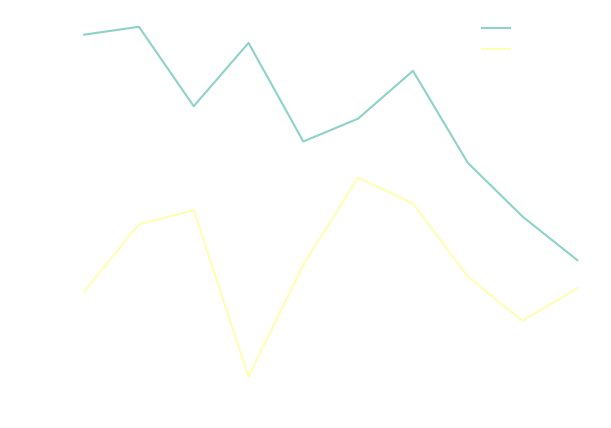

In [57]:
losses = np.array(losses)
x = np.arange(losses.shape[0]) * i_log
with plt.style.context(pyplot_context):
    fig, axes = plt.subplots(figsize=(7,5))
    axes.plot(x, losses[:,0], label='train')
    axes.plot(x, losses[:,1], label='validation')
    axes.patch.set_alpha(plot_alpha)
    fig.patch.set_alpha(plot_alpha)
    axes.legend(frameon=False)

Save the model and optionally copy to google drive

In [58]:
torch.save(model.state_dict(), 'flow_matching_model_transformer.pt') # Save with a new name
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/flow/', exist_ok=True)
!cp flow_matching_model_transformer.pt "/content/drive/MyDrive/Colab Notebooks/flow/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Flow Model Evaluation

### Model Sampling

Here some things about how sampling works.

In [43]:
def do_flow_matching_sampling(model, x_1, num_sampling_steps, y=None):
    x_t = torch.clone(x_1) # Start from noise (x_1 at t=1)
    dt = 1.0 / num_sampling_steps

    model.eval()
    with torch.no_grad():
        for i in range(num_sampling_steps):
            t_float_current = 1.0 - i * dt  # Current time t for x_t

            # Ensure time tensors match the batch size and expected shape for the model
            t_current_tensor = t_float_current * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

            # RK4 steps for backward integration
            # k1 = dt * v(x_t, t)
            v1 = model(x_t, t_current_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k1 = v1 * dt

            # k2 = dt * v(x_t - 0.5 * k1, t - 0.5 * dt)
            x_k2_input = x_t - 0.5 * k1
            t_k2_float = t_float_current - 0.5 * dt
            t_k2_tensor = t_k2_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v2 = model(x_k2_input, t_k2_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k2 = v2 * dt

            # k3 = dt * v(x_t - 0.5 * k2, t - 0.5 * dt)
            x_k3_input = x_t - 0.5 * k2
            t_k3_float = t_float_current - 0.5 * dt # Same time as t_k2_float
            t_k3_tensor = t_k3_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v3 = model(x_k3_input, t_k3_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k3 = v3 * dt

            # k4 = dt * v(x_t - k3, t - dt)
            x_k4_input = x_t - k3
            t_k4_float = t_float_current - dt
            t_k4_tensor = t_k4_float * torch.ones(x_t.shape[0], device=device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            v4 = model(x_k4_input, t_k4_tensor.squeeze(-1).squeeze(-1).squeeze(-1), y)
            k4 = v4 * dt

            # Update x_t using the RK4 formula for backward integration
            x_t = x_t - (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    return x_t

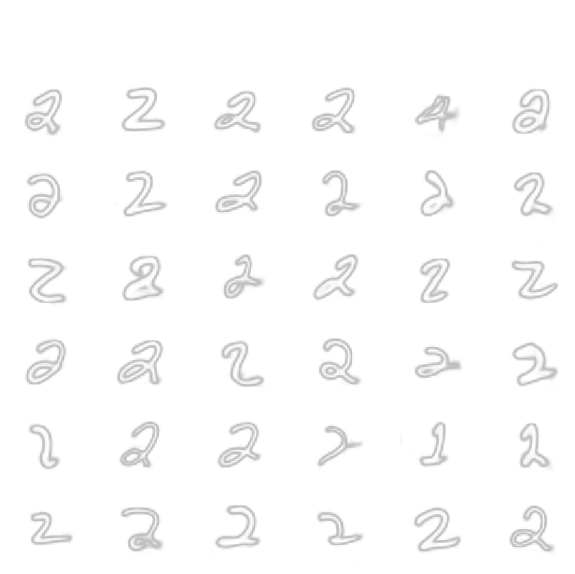

In [67]:
with torch.no_grad():
    model.eval() # Use the new 'model' (Transformer-based)
    num_samples = 36 # Total number of images to generate and display
    sampling_steps = 50 # Number of steps for ODE solver

    # Generate initial noise (x_1 in the Flow Matching context)
    eval_shape = (num_samples,) + lat_val.shape[1:]
    N = torch.normal(0, 1, eval_shape, device=device)

    # Create conditional labels for the generated samples
    conditional_class = 2 # The digit we want to generate
    y_labels = conditional_class * torch.ones(num_samples, dtype=torch.long, device=device)

    # Perform Flow Matching sampling
    pred = do_flow_matching_sampling(model, N, sampling_steps, y=y_labels)

    decoder.eval()
    pred = decoder(pred).cpu().numpy()

    with plt.style.context(pyplot_context):
        fig, axes = plt.subplots(6, 6, figsize=(6,6))
        fig.suptitle(f'Generated Digit: {conditional_class}', fontsize=16)
        for i in range(num_samples):
            img = np.clip(pred[i,0,:,:].T, -1.0, 1.0)
            axes[i//6,i%6].imshow(img, cmap=binary_cmap)
            axes[i//6,i%6].axis('off')
            axes[i//6,i%6].patch.set_alpha(plot_alpha)
        fig.patch.set_alpha(plot_alpha)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

벡터장의 모양

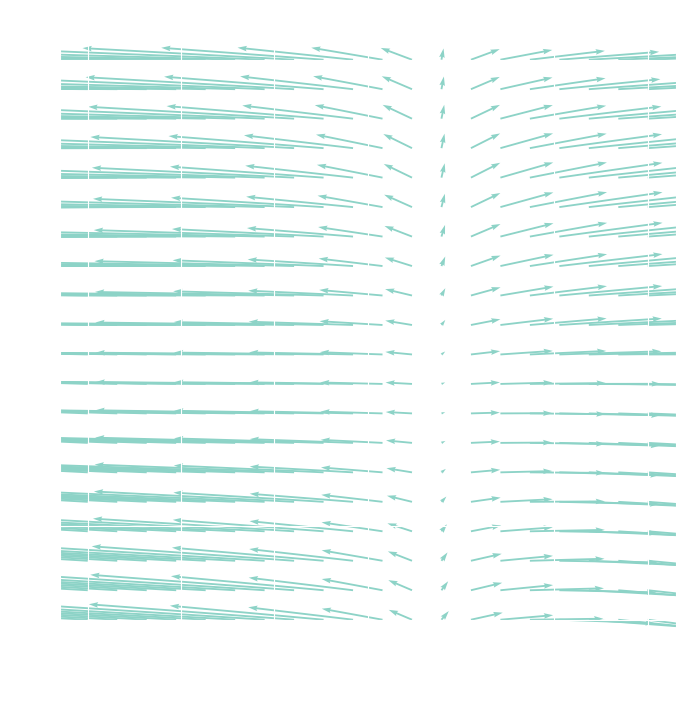

In [60]:
def plot_latent_vector_field(
    model_to_plot, # Renamed parameter to avoid conflict if 'model' is global
    latent_resolution,
    latent_channels,
    t_value,
    conditional_class,
    spatial_row=1, # Changed default from 4 to 1
    spatial_col=1, # Changed default from 4 to 1
    grid_range=(-3, 3, 20)
):
    model_to_plot.eval() # Set model to evaluation mode
    with torch.no_grad():
        # Define the 2D grid for latent channel values
        grid_min, grid_max, grid_points = grid_range
        x_coords = torch.linspace(grid_min, grid_max, grid_points, device=device)
        y_coords = torch.linspace(grid_min, grid_max, grid_points, device=device)
        X, Y = torch.meshgrid(x_coords, y_coords, indexing='ij')

        # Prepare input tensors for the model
        # We will create a batch of inputs, where each input corresponds to a grid point
        batch_size = grid_points * grid_points

        # Initialize x_t with zeros or a representative value for other latent spatial locations
        x_t_base = torch.zeros(
            (1, latent_channels, latent_resolution, latent_resolution),
            device=device
        )

        # Expand x_t_base to match batch_size
        x_t_batch = x_t_base.repeat(batch_size, 1, 1, 1)

        # Fill the varying latent channel values at the chosen spatial location
        idx = 0
        for i in range(grid_points):
            for j in range(grid_points):
                x_t_batch[idx, 0, spatial_row, spatial_col] = X[i, j]
                x_t_batch[idx, 1, spatial_row, spatial_col] = Y[i, j]
                idx += 1

        # Prepare time and class embeddings
        t_tensor = t_value * torch.ones(batch_size, device=device)
        y_tensor = conditional_class * torch.ones(batch_size, dtype=torch.long, device=device)

        # Predict the vector field
        v_theta_batch = model_to_plot(x_t_batch, t_tensor, y_tensor)

        # Extract the vector components at the specific spatial location
        U_values = v_theta_batch[:, 0, spatial_row, spatial_col].cpu().numpy()
        V_values = v_theta_batch[:, 1, spatial_row, spatial_col].cpu().numpy()

        # Reshape for quiver plot
        U = U_values.reshape(grid_points, grid_points)
        V = V_values.reshape(grid_points, grid_points)

        # Plotting
        with plt.style.context(pyplot_context):
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.quiver(X.cpu().numpy(), Y.cpu().numpy(), U, V, color='C0', scale_units='xy', angles='xy', scale=1)
            ax.set_title(f'Latent Vector Field at t={t_value}, Class={conditional_class}, Spatial Loc=({spatial_row},{spatial_col})')
            ax.set_xlabel(f'Latent Channel 0 Value at ({spatial_row},{spatial_col})')
            ax.set_ylabel(f'Latent Channel 1 Value at ({spatial_row},{spatial_col})')
            ax.set_aspect('equal', adjustable='box')
            ax.patch.set_alpha(plot_alpha)
            fig.patch.set_alpha(plot_alpha)
            plt.grid(True)
            plt.show()

# Example usage:
# Choose a time 't' and a class 'y' to visualize the vector field
t_to_plot = 0.5
conditional_class_to_plot = 6 # e.g., digit '6'

# Call the function to plot the vector field
plot_latent_vector_field(
    model, # Pass the new Transformer-based model
    latent_resolution,
    latent_channels,
    t_value=t_to_plot,
    conditional_class=conditional_class_to_plot,
    spatial_row=1, # Explicitly setting valid spatial_row
    spatial_col=1  # Explicitly setting valid spatial_col
)

### Fréchet inception distance

The Fréchet distance is a measure of simlarity of two distributions. For two multidimensional Gaussian distributions, the distance is calculated as,
$$
d_F = \left| \mu_A - \mu_B \right|^2 + tr( \Sigma_A + \Sigma_B - 2 \sqrt{\Sigma_A \Sigma_B} )
$$
The Fréchet *inception* distance compares the output of the last layer before the classification layer of [inceptionv3](https://en.wikipedia.org/wiki/Inceptionv3). Here, instead, we use a much simplified classifier.

In [30]:
class Classifier(torch.nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()

        self.layers = torch.nn.Sequential(
            # 1x32x32
            torch.nn.Conv2d(1, 8, 3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            # 8x16x16
            torch.nn.Conv2d(8, 16, 3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            # 16x8x8
            torch.nn.Conv2d(16, 32, 3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(4, 4),

            # 32x2x2
            torch.nn.Flatten(),
            torch.nn.Dropout(),
        )

        self.classification_layer = torch.nn.Sequential(
            torch.nn.Linear(128, 10),
        )

    def forward(self, x):
        y = self.layers(x)
        y = self.classification_layer(y)
        return y

classifier = Classifier()
classifier = classifier.to(device)

If your Classifier is saved, you can load it from your google drive.

In [31]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!cp "/content/drive/MyDrive/Colab Notebooks/classifier/classifier.pt" .
classifier.load_state_dict(torch.load('classifier.pt', map_location=device))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<All keys matched successfully>

신규로 Classifier 학습

In [ ]:
optimizer = torch.optim.Adam(classifier.parameters(), learning_rate)

i_log = 10
num_batches = int(math.ceil(lat_train.shape[0] / batch_size))
num_batches_val = int(math.ceil(lat_val.shape[0] / batch_size))

losses = []
for i in range(num_epochs):
    model.train()
    train_ids = torch.randperm(lat_train.shape[0])
    average_loss = 0.0
    for bid in range(num_batches):

        with torch.no_grad():
            batch_ids = train_ids[bid*batch_size:(bid+1)*batch_size]
            x = x_train[batch_ids,None,...,0]
            y = y_train[batch_ids,...]
            y = y.to(device)
            x = x.to(device)

        y_pred = classifier(x)
        loss = cross_entropy(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            average_loss += loss.cpu().numpy() / num_batches

    if (i + 1) % i_log == 0:
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bid in range(num_batches_val):
                y = y_val[bid*batch_size:(bid+1)*batch_size,...].to(device)
                x = x_val[bid*batch_size:(bid+1)*batch_size,None,...,0].to(device)
                y_pred = classifier(x)
                loss = cross_entropy(y_pred, y)
                val_loss += loss.cpu().numpy()

        val_loss /= num_batches_val
        losses.append([average_loss, val_loss])
        print(f'Epoch {i} loss = {average_loss}, val_loss = {val_loss}')


Epoch 9 loss = 0.07109985500574112, val_loss = 0.06946387141942978
Epoch 19 loss = 0.060401320457458496, val_loss = 0.06524866074323654
Epoch 29 loss = 0.05704311653971672, val_loss = 0.06439075618982315
Epoch 39 loss = 0.05209057778120041, val_loss = 0.06544092297554016
Epoch 49 loss = 0.047258708626031876, val_loss = 0.06303383409976959
Epoch 59 loss = 0.04747723788022995, val_loss = 0.06634481251239777
Epoch 69 loss = 0.046354182064533234, val_loss = 0.05711584910750389
Epoch 79 loss = 0.0436905100941658, val_loss = 0.06363432854413986
Epoch 89 loss = 0.041648756712675095, val_loss = 0.06037016212940216
Epoch 99 loss = 0.03899851813912392, val_loss = 0.055735182017087936
Epoch 109 loss = 0.03952137753367424, val_loss = 0.06457993388175964
Epoch 119 loss = 0.03916054964065552, val_loss = 0.060826532542705536
Epoch 129 loss = 0.03744611144065857, val_loss = 0.05886342376470566
Epoch 139 loss = 0.03636690601706505, val_loss = 0.05689403787255287
Epoch 149 loss = 0.03893045336008072, va

In [ ]:
torch.save(classifier.state_dict(), 'classifier.pt')
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/classifier/', exist_ok=True)
!cp classifier.pt "/content/drive/MyDrive/Colab Notebooks/classifier/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Classifier의 성능 평가

In [32]:
classifier.eval()
with torch.no_grad():
    y_val_pred = classifier(x_val[:,None,...,0].to(device)).cpu().numpy()

accuracy = np.mean(np.argmax(y_val_pred, axis=-1) == y_val.cpu().numpy())
print(f'Model accuracy: {100.0 * accuracy:.2f}%')

Model accuracy: 99.20%


Let us use the Flow Matching model to generate a synthetic dataset with size equal to the validation set.

In [61]:
batch_size_eval = 1024
num_batches_val = int(math.ceil(x_val.shape[0] / batch_size_eval))
num_sampling_steps = 50 # Number of steps for ODE solver

x_gen = []
x_gen_vae = []
with torch.no_grad():
    model.eval() # Use the new 'model' (Transformer-based)
    decoder.eval()
    for bi in range(num_batches_val):
        size = batch_size_eval
        if bi == num_batches_val - 1:
            size = x_val.shape[0] - bi * batch_size_eval

        eval_shape = (size,) + lat_val.shape[1:]
        N = torch.normal(0, 1, eval_shape, device=device)

        # Perform Flow Matching sampling
        pred = do_flow_matching_sampling(model, N, num_sampling_steps) # Pass the new model
        pred = decoder(pred).cpu().numpy()
        x_gen.append(pred)

        z = torch.normal(0, 1.0, size=(size, latent_channels, 4, 4), device=device)
        pred = decoder(z).cpu().numpy()
        x_gen_vae.append(pred)

x_gen     = np.concatenate(x_gen)
x_gen_vae = np.concatenate(x_gen_vae)

We will now use the classifier to evaluate the layer before classification for our generated dataset, as well as for the validation and training dataset. We also create one with random values to compare to in the end.

In [62]:
classifier.eval()
with torch.no_grad():
    x = x_val[:,None,:,:,0].to(device)
    latent_val = classifier.layers(x)

    x = x_train[:,None,:,:,0].to(device)
    latent_train = classifier.layers(x)

    x = torch.from_numpy(x_gen).to(device)
    x = torch.transpose(x, 2, 3)
    latent_gen = classifier.layers(x)

    x = torch.from_numpy(x_gen_vae).to(device)
    x = torch.transpose(x, 2, 3)
    latent_gen_vae = classifier.layers(x)

    latent_rand = torch.randn(latent_gen.shape, device=device)
    mu    = torch.std(latent_train, dim=0)
    sigma = torch.mean(latent_train, dim=0)
    latent_rand = latent_rand * mu + sigma

Applying the classification layer to the latent variables, we can evaluate the labels for the different datasets.

In [63]:
labels_gen     = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_gen), dim=-1), dim=-1).cpu().numpy()
labels_gen_vae = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_gen_vae), dim=-1), dim=-1).cpu().numpy()
labels_val     = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_val), dim=-1), dim=-1).cpu().numpy()
labels_train   = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_train), dim=-1), dim=-1).cpu().numpy()
labels_rand    = torch.argmax(torch.nn.functional.softmax(classifier.classification_layer(latent_rand), dim=-1), dim=-1).cpu().numpy()

Let's plot a historgram of the generated and validation set labels and see how close the distributions are.

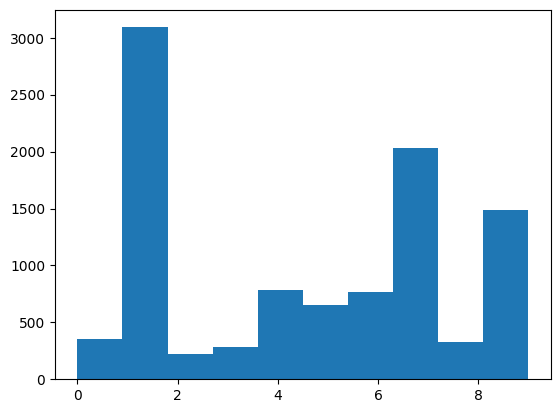

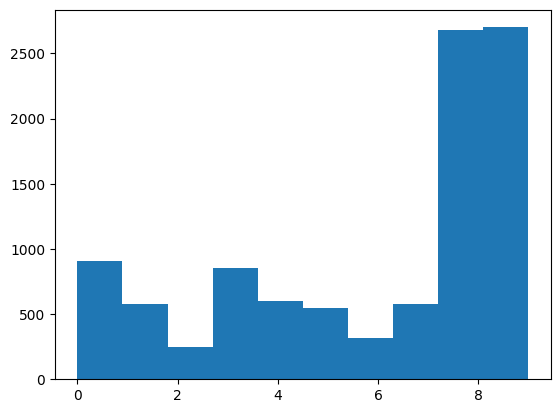

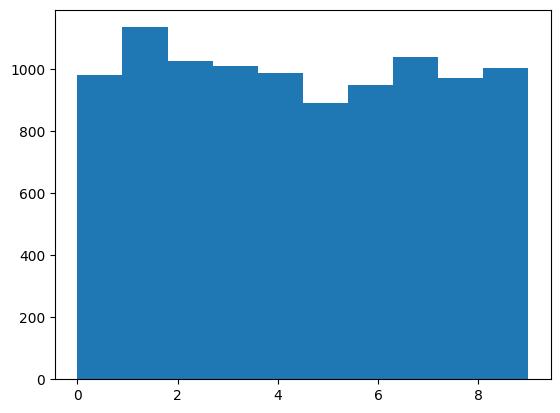

In [64]:
plt.hist(labels_gen_vae)
plt.show()
plt.hist(labels_gen)
plt.show()
plt.hist(labels_val)
plt.show()

That's not bad, but there is definitely a difference there. Let us now evaluate the Fréchet distance!

In [37]:
def frechet_distance(x_a, x_b):
    mu_a    = np.mean(x_a, axis=0)
    sigma_a = np.cov(x_a.T)
    mu_b    = np.mean(x_b, axis=0)
    sigma_b = np.cov(x_b.T)

    diff = mu_a - mu_b
    covmean = scipy.linalg.sqrtm(sigma_a @ sigma_b)
    return np.sum(diff**2) + np.trace(sigma_a + sigma_b - 2.0 * covmean)

In [65]:
latent_val     = latent_val.cpu().numpy()
latent_rand    = latent_rand.cpu().numpy()
latent_gen     = latent_gen.cpu().numpy()
latent_gen_vae = latent_gen_vae.cpu().numpy()
latent_train   = latent_train.cpu().numpy()

In [66]:
print('Random:    ', frechet_distance(latent_rand, latent_val))
print('VAE:       ', frechet_distance(latent_gen_vae, latent_val))
print('Flow Matching: ', frechet_distance(latent_gen, latent_val))
print('Validation:', frechet_distance(latent_val, latent_train))

/tmp/ipykernel_15476/3532828688.py:8: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = scipy.linalg.sqrtm(sigma_a @ sigma_b)


Random:     42.86458197034165
VAE:        34.00997590475748
Flow Matching:  25.662424262592673
Validation: 0.26918953220412906


Our generated data fair quite a bit better than random, but also the VAE. If we compare with the validation set, though, we still have room for improvement!